## **Supervised Model III – XGBoost (Improved)**

Key changes from XGBoost_improved5:
1. **Usage of unsupervised models and scores**
Cell 9 — build_unsupervised_scores now fits IF, LOF, and Mahalanobis on X_handcrafted_ref directly ***(all users)*** instead of filtering to ref_labels == 0. LOF is back as the 4th unsupervised feature. The ref_labels parameter is removed from the function signature entirely. SVD reconstruction is still normal-only (that one actually works). UNSUP_COLS is now 5 columns: svd_recon_mse, svd_recon_mae, iso_score, lof_score, maha_score.

Still includes three fixes from previous round (calibration alignment fix, structural refs fix, and early stopping within final training)

This is an improved version, first built upon XGBoost_v3c. The changes listed below are with reference to that notebook.

Internal CV data leakage has been fixed, but the optuna search still uses global statistics, which may be slightly optimistic (it may be too costly/time consuming to recalculate stats for each trial, and i dont know if the gain is worth it, but you can try)

1. **Features (24 → 36):**
Added 7 structural features (KL divergence from global rating distribution, Gini coefficient of item selection, rating mode fraction, skewness, kurtosis, fraction of top-100 items rated, ratings-per-item ratio). Added 5 unsupervised features (SVD reconstruction MSE and MAE fitted on normal users only, plus Isolation Forest, LOF, and Mahalanobis fitted on all users in handcrafted feature space).


2. **Structural features – no data leakage:**
New compute_structural_refs function extracts global rating distribution and top-100 item set from training data only. Both train and validation/test users are measured against these frozen references.


3. **SVD reconstruction error:**
Sparse user-item matrix built per user, TruncatedSVD (50 components) fitted on normal users' interactions only. Reconstruction MSE and MAE on rated items used as features — captures rating inconsistency independent of latent position.


4. **Unsupervised anomaly scores:**
IF, LOF, and Mahalanobis computed on scaled handcrafted features with all-user fitting. Normal-only fitting was tested but empirically performed worse (IF dropped from 0.692 to 0.637 AUC).


5. **Fold-isolated feature engineering:**
Item stats, structural refs, SVD model, scaler, and unsupervised models all computed per CV fold from training data only, preventing data leakage in OOF estimates.


6. **Optuna objective changed to F-beta (β=1.5):**
Biases hyperparameter search toward recall, since test recall was the primary bottleneck due to unseen anomaly groups.


7. **CV reduced from 20-fold to 5-fold:**
Each fold has ~52 anomalous users instead of ~13, giving more stable AUC/F1 estimates and more diverse ensemble members.


8. **Early stopping added to final CV:**
Validation fold used as eval set with early_stopping_rounds=50, matching the Optuna search configuration and preventing overfitting past the intended tree count.


9. **Blended calibration:**
OOF SVD recon MSE collected per fold, blended with OOF XGBoost scores at BLEND_ALPHA, then calibrator fitted on the blended distribution — matching exactly what happens at test time.


10. **Test-time blending:**
Standalone SVD reconstruction MSE blended with XGBoost ensemble scores at BLEND_ALPHA=0.08 before calibration, providing a small safety net for unseen anomaly groups.

In [24]:
results = []

In [ ]:
import matplotlib.pyplot as plt
import zipfile, warnings
import xgboost as xgb
import pandas as pd
import numpy as np
import optuna
from scipy.stats import entropy
from scipy.spatial.distance import mahalanobis
from scipy.sparse import csr_matrix
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import TruncatedSVD, NMF


warnings.filterwarnings('ignore')

TOTAL_ITEMS = 1000
RATING_RANGE = range(6)
N_SVD_COMPONENTS = 50

/Users/tori/Documents/OFFICES/SCHOOL/Y3S2/Machine_Learning_421_SMU/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### **Data Loading**

In [3]:
# ── I/O helpers ──────────────────────────────────────────────────────

def load_npz(path: str) -> tuple[pd.DataFrame, pd.DataFrame | None]:
    data = np.load(path)
    XX = pd.DataFrame(data["X"], columns=["user", "item", "rating"])
    yy = None
    if "y" in data:
        yy = pd.DataFrame(data["y"], columns=["user", "label"])
    return XX, yy


def combine_labeled_data(
    *npz_paths: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_X, all_y = [], []
    for path in npz_paths:
        data = np.load(path)
        all_X.append(pd.DataFrame(data["X"], columns=["user", "item", "rating"]))
        all_y.append(pd.DataFrame(data["y"], columns=["user", "label"]))

    XX = pd.concat(all_X, ignore_index=True)
    yy = pd.concat(all_y, ignore_index=True).drop_duplicates(subset="user", keep="first")

    n_anom = int(yy["label"].sum())
    print(f"Combined {len(npz_paths)} files")
    print(f"{yy.shape[0]} users ({n_anom} anomalous, {yy.shape[0] - n_anom} normal), {XX.shape[0]} interactions")
    return XX, yy

In [4]:
# ── Sparse matrix builder ────────────────────────────────────────────

def build_user_item_matrix(XX: pd.DataFrame, user_ids: np.ndarray):
    """Build a sparse user×item rating matrix.
    
    Returns:
        mat: sparse CSR matrix (n_users × TOTAL_ITEMS)
        uid_to_row: dict mapping user_id → row index
    """
    uid_to_row = {uid: i for i, uid in enumerate(user_ids)}

    # Vectorised — avoid iterrows on 400k+ rows
    mask = XX["user"].isin(uid_to_row)
    sub = XX.loc[mask]
    rows = sub["user"].map(uid_to_row).values
    cols = sub["item"].values.astype(int)
    vals = sub["rating"].values.astype(float)

    mat = csr_matrix((vals, (rows, cols)), shape=(len(user_ids), TOTAL_ITEMS))
    return mat, uid_to_row

In [5]:
# ── Original hand-crafted features (kept from your notebook) ────────

def compute_item_stats(XX_train: pd.DataFrame) -> dict:
    item_avg = XX_train.groupby("item")["rating"].mean().rename("item_avg_rating")
    item_pop = XX_train.groupby("item")["user"].count().rename("item_popularity")
    return {"item_avg_rating": item_avg, "item_popularity": item_pop}


def build_handcrafted_features(
    XX: pd.DataFrame,
    item_stats: dict,
    total_items: int = TOTAL_ITEMS,
) -> pd.DataFrame:
    """Original 24 features — unchanged from your notebook."""
    item_avg = item_stats["item_avg_rating"]
    item_pop = item_stats["item_popularity"]

    stats = XX.groupby("user")["rating"].agg(
        rating_mean="mean", rating_std="std", rating_median="median",
        rating_min="min", rating_max="max", rating_count="count",
    )
    stats["rating_std"] = stats["rating_std"].fillna(0)
    stats["rating_range"] = stats["rating_max"] - stats["rating_min"]

    rdist = XX.groupby(["user", "rating"]).size().unstack(fill_value=0)
    rdist = rdist.reindex(columns=RATING_RANGE, fill_value=0)
    rprops = rdist.div(rdist.sum(axis=1), axis=0)
    rprops.columns = [f"prop_rating_{i}" for i in RATING_RANGE]
    stats["rating_entropy"] = rprops.apply(
        lambda row: entropy(row.values[row.values > 0]), axis=1
    )
    stats = stats.join(rprops)
    stats["prop_extreme"] = rprops["prop_rating_0"] + rprops["prop_rating_5"]

    stats["unique_items_rated"] = XX.groupby("user")["item"].nunique()
    stats["item_coverage_ratio"] = stats["unique_items_rated"] / total_items

    XX_pop = XX.merge(item_pop, left_on="item", right_index=True, how="left")
    XX_pop["item_popularity"] = XX_pop["item_popularity"].fillna(0)
    pop_f = XX_pop.groupby("user")["item_popularity"].agg(
        avg_item_popularity="mean", std_item_popularity="std",
    )
    pop_f["std_item_popularity"] = pop_f["std_item_popularity"].fillna(0)
    stats = stats.join(pop_f)

    XX_dev = XX.merge(item_avg, left_on="item", right_index=True, how="left")
    global_train_mean = item_avg.mean()
    XX_dev["item_avg_rating"] = XX_dev["item_avg_rating"].fillna(global_train_mean)
    XX_dev["deviation"] = XX_dev["rating"] - XX_dev["item_avg_rating"]
    dev_f = XX_dev.groupby("user")["deviation"].agg(
        mean_deviation="mean", std_deviation="std",
        abs_mean_deviation=lambda x: np.mean(np.abs(x)),
    )
    dev_f["std_deviation"] = dev_f["std_deviation"].fillna(0)
    stats = stats.join(dev_f)

    iqf = XX_dev.groupby("user")["item_avg_rating"].agg(
        avg_item_avg_rating="mean", std_item_avg_rating="std",
    )
    iqf["std_item_avg_rating"] = iqf["std_item_avg_rating"].fillna(0)
    stats = stats.join(iqf)

    return stats.reset_index()

In [6]:
# ── Structural features (with reference stats to prevent leakage) ────

def compute_structural_refs(XX_train: pd.DataFrame) -> dict:
    """Compute reference statistics from TRAINING data only.
    Pass the returned dict to build_structural_features for both
    train and test/val to prevent leakage.
    """
    global_dist = XX_train["rating"].value_counts(normalize=True).reindex(RATING_RANGE, fill_value=0).values
    global_dist = np.clip(global_dist, 1e-10, None)
    top_items = set(XX_train["item"].value_counts().head(100).index)
    return {"global_dist": global_dist, "top_items": top_items}


def build_structural_features(
    XX: pd.DataFrame,
    structural_refs: dict,
) -> pd.DataFrame:
    """Features that capture the *shape* of a user's behaviour.
    Uses frozen reference stats from training data for KL divergence
    and top-item overlap to prevent train/val leakage.
    """
    feats = pd.DataFrame({"user": XX["user"].unique()})

    # ── KL divergence from TRAINING global distribution ────────────
    ref_dist = structural_refs["global_dist"]

    def user_kl(group):
        user_dist = group["rating"].value_counts(normalize=True).reindex(RATING_RANGE, fill_value=0).values
        user_dist = np.clip(user_dist, 1e-10, None)
        return entropy(user_dist, ref_dist)

    kl_df = XX.groupby("user").apply(user_kl).rename("kl_div_from_global")
    feats = feats.merge(kl_df, on="user", how="left")

    # ── Gini coefficient of item selection ────────────────────────
    def gini_coeff(group):
        counts = group["item"].value_counts().values.astype(float)
        if len(counts) <= 1:
            return 0.0
        counts = np.sort(counts)
        n = len(counts)
        index = np.arange(1, n + 1)
        return (2.0 * np.sum(index * counts) / (n * np.sum(counts))) - (n + 1.0) / n

    gini_df = XX.groupby("user").apply(gini_coeff).rename("item_gini")
    feats = feats.merge(gini_df, on="user", how="left")

    # ── Rating flatness ──────────────────────────────────────────
    def rating_flatness(group):
        ratings = group["rating"].values
        if len(ratings) <= 1:
            return 0.0
        vals, counts = np.unique(ratings, return_counts=True)
        return counts.max() / len(ratings)

    flat_df = XX.groupby("user").apply(rating_flatness).rename("rating_mode_frac")
    feats = feats.merge(flat_df, on="user", how="left")

    # ── Rating skewness & kurtosis ───────────────────────────────
    skew_df = XX.groupby("user")["rating"].skew().rename("rating_skew").fillna(0)
    kurt_df = XX.groupby("user")["rating"].apply(
        lambda x: x.kurtosis() if len(x) >= 4 else 0.0
    ).rename("rating_kurtosis")
    feats = feats.merge(skew_df, on="user", how="left")
    feats = feats.merge(kurt_df, on="user", how="left")

    # ── Item overlap with TRAINING top-100 items ─────────────────
    ref_top = structural_refs["top_items"]
    def top_item_frac(group):
        user_items = set(group["item"].values)
        return len(user_items & ref_top) / max(len(user_items), 1)

    top_df = XX.groupby("user").apply(top_item_frac).rename("frac_top100_items")
    feats = feats.merge(top_df, on="user", how="left")

    # ── Ratings-per-item ratio ───────────────────────────────────
    rpi = XX.groupby("user").apply(
        lambda g: len(g) / g["item"].nunique()
    ).rename("ratings_per_item")
    feats = feats.merge(rpi, on="user", how="left")

    return feats


In [7]:
# ── (SVD + unsupervised scoring merged into build_unsupervised_scores) ─
pass


In [8]:
# ── Unsupervised scores ───────────────────────────────────────────────
#
# SVD recon error: fitted on NORMAL users only (latent space)
# IF, LOF, Maha: fitted on ALL users (handcrafted space)
#   - All-user fitting empirically outperformed normal-only
#   - LOF added back as XGBoost feature (useful in interactions)

def build_unsupervised_scores(
    XX_ref: pd.DataFrame,
    XX_target: pd.DataFrame,
    target_users: np.ndarray,
    ref_normal_users: np.ndarray,
    X_handcrafted_ref: np.ndarray,
    X_handcrafted_target: np.ndarray,
    n_components: int = N_SVD_COMPONENTS,
) -> tuple[np.ndarray, TruncatedSVD]:
    """Compute unsupervised features.

    Returns (scores_array, svd_model) where scores_array has columns:
      [svd_recon_mse, svd_recon_mae, iso_score, lof_score, maha_score]
    """
    # ─── A) SVD reconstruction error (normal-only fit) ─────────────
    XX_normal = XX_ref[XX_ref["user"].isin(ref_normal_users)]
    normal_uids = XX_normal["user"].unique()
    normal_mat, _ = build_user_item_matrix(XX_normal, normal_uids)

    n_comp = min(n_components, min(normal_mat.shape) - 1)
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    svd.fit(normal_mat)

    target_mat, _ = build_user_item_matrix(XX_target, target_users)
    latent = svd.transform(target_mat)
    reconstructed = latent @ svd.components_

    target_dense = target_mat.toarray()
    mask = (target_dense != 0).astype(float)
    diff = (target_dense - reconstructed) * mask
    n_rated = np.maximum(np.sum(mask, axis=1), 1)

    recon_mse = np.sum(diff ** 2, axis=1) / n_rated
    recon_mae = np.sum(np.abs(diff), axis=1) / n_rated

    # ─── B) IF + LOF + Maha on ALL handcrafted features ───────────
    iso = IsolationForest(
        n_estimators=500, contamination="auto", random_state=42, n_jobs=-1
    )
    iso.fit(X_handcrafted_ref)
    iso_scores = -iso.score_samples(X_handcrafted_target)

    n_neighbors = min(20, len(X_handcrafted_ref) - 1)
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors, contamination="auto", novelty=True, n_jobs=-1
    )
    lof.fit(X_handcrafted_ref)
    lof_scores = -lof.score_samples(X_handcrafted_target)

    try:
        mu = X_handcrafted_ref.mean(axis=0)
        cov = np.cov(X_handcrafted_ref, rowvar=False)
        cov += np.eye(cov.shape[0]) * 1e-6
        cov_inv = np.linalg.inv(cov)
        maha_scores = np.array([
            mahalanobis(x, mu, cov_inv) for x in X_handcrafted_target
        ])
    except Exception:
        mu = X_handcrafted_ref.mean(axis=0)
        maha_scores = np.linalg.norm(X_handcrafted_target - mu, axis=1)

    scores = np.column_stack([recon_mse, recon_mae, iso_scores, lof_scores, maha_scores])
    return scores, svd


UNSUP_COLS = [
    "svd_recon_mse", "svd_recon_mae",
    "iso_score", "lof_score", "maha_score",
]


In [9]:
# ── Combined feature pipeline ────────────────────────────────────────

def build_all_features(
    XX: pd.DataFrame,
    item_stats: dict,
    structural_refs: dict,
) -> pd.DataFrame:
    """Merge handcrafted + structural features.
    structural_refs must come from compute_structural_refs(XX_train).
    """
    hc = build_handcrafted_features(XX, item_stats)
    st = build_structural_features(XX, structural_refs)
    merged = hc.merge(st, on="user", how="left")
    return merged


In [10]:
# ── Fold feature builder ──────────────────────────────────────────────

def make_fold_features_v2(XX_raw, yy_raw, train_users, val_users):
    XX_tr  = XX_raw[XX_raw["user"].isin(train_users)].copy()
    XX_val = XX_raw[XX_raw["user"].isin(val_users)].copy()
    yy_tr  = yy_raw[yy_raw["user"].isin(train_users)].copy()
    yy_val = yy_raw[yy_raw["user"].isin(val_users)].copy()

    normal_train_users = yy_tr[yy_tr["label"] == 0]["user"].values
    item_stats_tr = compute_item_stats(XX_tr)
    struct_refs_tr = compute_structural_refs(XX_tr)

    feats_tr  = build_all_features(XX_tr, item_stats_tr, struct_refs_tr).merge(yy_tr, on="user")
    feats_val = build_all_features(XX_val, item_stats_tr, struct_refs_tr).merge(yy_val, on="user")

    hc_cols = [c for c in feats_tr.columns if c not in ["user", "label"]]

    scaler_fold = RobustScaler()
    X_tr_hc_s = scaler_fold.fit_transform(feats_tr[hc_cols].values)
    X_val_hc_s = scaler_fold.transform(feats_val[hc_cols].values)

    # Unsupervised: SVD recon (normal-only) + IF/LOF/Maha (all users)
    unsup_tr, svd_model = build_unsupervised_scores(
        XX_ref=XX_tr, XX_target=XX_tr,
        target_users=feats_tr["user"].values,
        ref_normal_users=normal_train_users,
        X_handcrafted_ref=X_tr_hc_s,
        X_handcrafted_target=X_tr_hc_s,
    )
    unsup_val, _ = build_unsupervised_scores(
        XX_ref=XX_tr, XX_target=XX_val,
        target_users=feats_val["user"].values,
        ref_normal_users=normal_train_users,
        X_handcrafted_ref=X_tr_hc_s,
        X_handcrafted_target=X_val_hc_s,
    )

    X_tr_final  = np.hstack([X_tr_hc_s, unsup_tr])
    X_val_final = np.hstack([X_val_hc_s, unsup_val])
    feature_cols_all = hc_cols + UNSUP_COLS

    val_recon_mse = unsup_val[:, 0]  # column 0 = svd_recon_mse

    return (
        X_tr_final, feats_tr["label"].values,
        X_val_final, feats_val["label"].values,
        item_stats_tr, feature_cols_all, scaler_fold, svd_model,
        normal_train_users, struct_refs_tr, val_recon_mse,
    )


In [11]:
# ── Evaluation helper ────────────────────────────────────────────────

def codabench_metrics(test_labels, scores, model_name, verbose=False):
    test_labels = np.asarray(test_labels).astype(int)
    scores = np.asarray(scores).astype(float)
    preds = (scores >= 0.5).astype(int)
    metrics = {
        "model": model_name,
        "AUC": roc_auc_score(test_labels, scores),
        "Precision": precision_score(test_labels, preds, zero_division=0),
        "Recall": recall_score(test_labels, preds, zero_division=0),
        "F1": f1_score(test_labels, preds, zero_division=0),
        "threshold": 0.5,
    }
    if verbose:
        print(f"{model_name} (Codabench t=0.5)")
        for k in ["AUC", "Precision", "Recall", "F1"]:
            print(f"# {k+':':12s} {metrics[k]:.4f}")
    return metrics

In [12]:
# Phase 3 data loading
XX_all, yy_all = combine_labeled_data(
    "data/training_batch_with_labels.npz",
    "data/first_batch_with_labels.npz",
    "data/second_batch_with_labels.npz",
)

Combined 3 files
3060 users (260 anomalous, 2800 normal), 479433 interactions


In [13]:
# Build full feature set for Optuna
item_stats_full = compute_item_stats(XX_all)
struct_refs_full = compute_structural_refs(XX_all)
full_train_df = build_all_features(XX_all, item_stats_full, struct_refs_full).merge(yy_all, on="user")

normal_users_all = yy_all[yy_all["label"] == 0]["user"].values
hc_cols = [c for c in full_train_df.columns if c not in ["user", "label"]]

scaler = RobustScaler()
X_hc_s = scaler.fit_transform(full_train_df[hc_cols].values)
y_trainval = full_train_df["label"].values

# Unsupervised scores (SVD normal-only, IF/LOF/Maha all-user)
unsup_all, svd_full_model = build_unsupervised_scores(
    XX_ref=XX_all, XX_target=XX_all,
    target_users=full_train_df["user"].values,
    ref_normal_users=normal_users_all,
    X_handcrafted_ref=X_hc_s,
    X_handcrafted_target=X_hc_s,
)

X_trainval_s = np.hstack([X_hc_s, unsup_all])
feature_cols = hc_cols
feature_cols_all = hc_cols + UNSUP_COLS

print(f"Training users: {len(y_trainval)}")
print(f"Features:       {len(feature_cols_all)}")
print(f"Feature names:  {feature_cols_all}")


Training users: 3060
Features:       36
Feature names:  ['rating_mean', 'rating_std', 'rating_median', 'rating_min', 'rating_max', 'rating_count', 'rating_range', 'rating_entropy', 'prop_rating_0', 'prop_rating_1', 'prop_rating_2', 'prop_rating_3', 'prop_rating_4', 'prop_rating_5', 'prop_extreme', 'unique_items_rated', 'item_coverage_ratio', 'avg_item_popularity', 'std_item_popularity', 'mean_deviation', 'std_deviation', 'abs_mean_deviation', 'avg_item_avg_rating', 'std_item_avg_rating', 'kl_div_from_global', 'item_gini', 'rating_mode_frac', 'rating_skew', 'rating_kurtosis', 'frac_top100_items', 'ratings_per_item', 'svd_recon_mse', 'svd_recon_mae', 'iso_score', 'lof_score', 'maha_score']


#### **Optuna Hyperparameter Search (F1-optimised)**

In [ ]:
spw_global = np.sum(y_trainval == 0) / np.sum(y_trainval == 1)
OPTUNA_BETA = 1.5  # >1 biases toward recall; try 1.5 or 2.0

def objective(trial):
    grow_policy = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])

    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 100, 4000),
        learning_rate     = trial.suggest_float("learning_rate", 0.001, 0.15, log=True),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        colsample_bynode  = trial.suggest_float("colsample_bynode", 0.4, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 1, 10),
        gamma             = trial.suggest_float("gamma", 0.0, 2.0),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        max_delta_step    = trial.suggest_int("max_delta_step", 0, 10),
        scale_pos_weight  = trial.suggest_float("scale_pos_weight", spw_global * 0.5, spw_global * 3.0),
        grow_policy       = grow_policy,
    )

    if grow_policy == "lossguide":
        params["max_leaves"] = trial.suggest_int("max_leaves", 16, 512)
    else:
        params["max_depth"] = trial.suggest_int("max_depth", 3, 12)

    # 5-fold CV, optimise for F-beta (recall-biased)
    # NOTE: minor leakage in unsup scores for speed; proper CV below.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=trial.number)
    fold_fbetas = []
    fold_f1s = []
    fold_aucs = []

    for tr_i, val_i in cv.split(X_trainval_s, y_trainval):
        m = xgb.XGBClassifier(
            **params,
            eval_metric="aucpr",
            early_stopping_rounds=50,
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
        )
        m.fit(
            X_trainval_s[tr_i], y_trainval[tr_i],
            eval_set=[(X_trainval_s[val_i], y_trainval[val_i])],
            verbose=False,
        )
        proba = m.predict_proba(X_trainval_s[val_i])[:, 1]
        preds = (proba >= 0.5).astype(int)
        fold_fbetas.append(fbeta_score(y_trainval[val_i], preds, beta=OPTUNA_BETA, zero_division=0))
        fold_f1s.append(f1_score(y_trainval[val_i], preds, zero_division=0))
        fold_aucs.append(roc_auc_score(y_trainval[val_i], proba))

    trial.set_user_attr("mean_auc", np.mean(fold_aucs))
    trial.set_user_attr("mean_f1", np.mean(fold_f1s))
    return np.mean(fold_fbetas)


In [15]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300, show_progress_bar=True)

best_params = study.best_params
print(f"Best CV F-beta({OPTUNA_BETA}): {study.best_value:.4f}")
print(f"Best CV F1:         {study.best_trial.user_attrs['mean_f1']:.4f}")
print(f"Best CV AUC:        {study.best_trial.user_attrs['mean_auc']:.4f}")
print("Best params:", best_params)


[I 2026-03-30 19:31:52,329] A new study created in memory with name: no-name-4eeee6b3-95f2-46b7-98f7-63a191ca0e0f
Best trial: 0. Best value: 0.760604:   0%|          | 1/300 [00:01<05:23,  1.08s/it]

[I 2026-03-30 19:31:53,412] Trial 0 finished with value: 0.7606043429869295 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 2990, 'learning_rate': 0.14956613887371137, 'subsample': 0.570285720263978, 'colsample_bytree': 0.42968379460554945, 'colsample_bylevel': 0.8675330749913945, 'colsample_bynode': 0.9748111570067438, 'min_child_weight': 9, 'gamma': 0.4293156484230265, 'reg_alpha': 1.4831780363113551, 'reg_lambda': 0.0014672695473475909, 'max_delta_step': 7, 'scale_pos_weight': 7.050303738464657, 'max_depth': 3}. Best is trial 0 with value: 0.7606043429869295.


Best trial: 0. Best value: 0.760604:   1%|          | 2/300 [00:02<06:25,  1.29s/it]

[I 2026-03-30 19:31:54,855] Trial 1 finished with value: 0.7540604956537333 and parameters: {'grow_policy': 'lossguide', 'n_estimators': 2432, 'learning_rate': 0.1396228081581116, 'subsample': 0.5672579082806585, 'colsample_bytree': 0.6637763271582122, 'colsample_bylevel': 0.862888956796373, 'colsample_bynode': 0.8942294178278288, 'min_child_weight': 9, 'gamma': 0.21054890139221238, 'reg_alpha': 0.011659009922098439, 'reg_lambda': 0.012610865767488164, 'max_delta_step': 8, 'scale_pos_weight': 17.44311859966967, 'max_leaves': 316}. Best is trial 0 with value: 0.7606043429869295.


Best trial: 2. Best value: 0.776488:   1%|          | 3/300 [00:05<10:12,  2.06s/it]

...

[I 2026-03-30 21:21:06,885] Trial 297 finished with value: 0.7731251846544744 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 2764, 'learning_rate': 0.04600638084692216, 'subsample': 0.6427928445081487, 'colsample_bytree': 0.9362995233909673, 'colsample_bylevel': 0.46477472185958696, 'colsample_bynode': 0.6442571750915232, 'min_child_weight': 7, 'gamma': 1.6790599022269583, 'reg_alpha': 3.2879711836904377, 'reg_lambda': 0.5218126941303446, 'max_delta_step': 5, 'scale_pos_weight': 9.741681895230371, 'max_depth': 8}. Best is trial 276 with value: 0.7929523905501545.


Best trial: 276. Best value: 0.792952: 100%|█████████▉| 299/300 [1:49:16<00:02,  2.08s/it]

[I 2026-03-30 21:21:08,728] Trial 298 finished with value: 0.7845757911723659 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 1965, 'learning_rate': 0.05797110445818411, 'subsample': 0.8173206837911005, 'colsample_bytree': 0.8757764481205437, 'colsample_bylevel': 0.4813328402823177, 'colsample_bynode': 0.8226387175197913, 'min_child_weight': 1, 'gamma': 1.5832377337277983, 'reg_alpha': 1.2810595132670932, 'reg_lambda': 0.00338919944860141, 'max_delta_step': 4, 'scale_pos_weight': 21.549113826922255, 'max_depth': 7}. Best is trial 276 with value: 0.7929523905501545.


Best trial: 276. Best value: 0.792952: 100%|██████████| 300/300 [1:49:18<00:00, 21.86s/it]

[I 2026-03-30 21:21:10,506] Trial 299 finished with value: 0.7748645949057282 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 1951, 'learning_rate': 0.0593906141904609, 'subsample': 0.8171817499123448, 'colsample_bytree': 0.8605433779960476, 'colsample_bylevel': 0.48108884727957607, 'colsample_bynode': 0.8437502278076027, 'min_child_weight': 1, 'gamma': 1.6083281619232088, 'reg_alpha': 1.3695310625577746, 'reg_lambda': 0.003847300908061815, 'max_delta_step': 3, 'scale_pos_weight': 21.241019512536354, 'max_depth': 7}. Best is trial 276 with value: 0.7929523905501545.
Best CV F-beta(1.5): 0.7930
Best CV F1:         0.7737
Best CV AUC:        0.9753
Best params: {'grow_policy': 'depthwise', 'n_estimators': 2901, 'learning_rate': 0.07613673235081583, 'subsample': 0.7152428207864439, 'colsample_bytree': 0.9904585629039329, 'colsample_bylevel': 0.8398763416609905, 'colsample_bynode': 0.7663700917859083, 'min_child_weight': 7, 'gamma': 1.1260298659495889, 'reg_alpha': 0.012576258

In [16]:
best_params = study.best_params
print(f"Best CV F-beta({OPTUNA_BETA}): {study.best_value:.4f}")
print(f"Best CV F1:         {study.best_trial.user_attrs['mean_f1']:.4f}")
print(f"Best CV AUC:        {study.best_trial.user_attrs['mean_auc']:.4f}")
print("Best params:", best_params)

Best CV F-beta(1.5): 0.7930
Best CV F1:         0.7737
Best CV AUC:        0.9753
Best params: {'grow_policy': 'depthwise', 'n_estimators': 2901, 'learning_rate': 0.07613673235081583, 'subsample': 0.7152428207864439, 'colsample_bytree': 0.9904585629039329, 'colsample_bylevel': 0.8398763416609905, 'colsample_bynode': 0.7663700917859083, 'min_child_weight': 7, 'gamma': 1.1260298659495889, 'reg_alpha': 0.012576258959702128, 'reg_lambda': 0.007058650708553599, 'max_delta_step': 4, 'scale_pos_weight': 22.177094671552904, 'max_depth': 9}


#### **Cross-Validation (5-fold)**

In [17]:
N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_scores = np.zeros(len(y_trainval))
oof_recon_mse = np.zeros(len(y_trainval))  # FIX 2: for blended calibration
fold_aucs = []
fold_f1s  = []
fold_artifacts = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(full_train_df[feature_cols].values, y_trainval), 1):
    train_users = full_train_df.iloc[tr_idx]["user"].values
    val_users   = full_train_df.iloc[va_idx]["user"].values

    X_tr, y_tr, X_va, y_va, item_stats_tr, feat_cols_fold, scaler_fold, svd_fold, \
        normal_users_fold, struct_refs_fold, val_recon_mse = \
        make_fold_features_v2(XX_all, yy_all, train_users, val_users)

    model = xgb.XGBClassifier(
        **best_params,
        eval_metric="auc",
        early_stopping_rounds=50,  # FIX 3: early stopping
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    # FIX 3: use validation fold as eval set for early stopping
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    p_va = model.predict_proba(X_va)[:, 1]
    oof_scores[va_idx] = p_va
    oof_recon_mse[va_idx] = val_recon_mse  # FIX 2: store OOF recon MSE

    fold_auc = roc_auc_score(y_va, p_va)
    fold_f1  = f1_score(y_va, (p_va >= 0.5).astype(int), zero_division=0)
    fold_aucs.append(fold_auc)
    fold_f1s.append(fold_f1)

    fold_artifacts.append({
        "model": model,
        "item_stats": item_stats_tr,
        "feature_cols": feat_cols_fold,
        "scaler": scaler_fold,
        "svd": svd_fold,
        "normal_users": normal_users_fold,
        "struct_refs": struct_refs_fold,
    })

    print(f"Fold {fold:02d}  AUC: {fold_auc:.4f}  F1: {fold_f1:.4f}  trees: {model.best_iteration + 1}")

print(f"\nMean fold AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Mean fold F1:  {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"OOF AUC:       {roc_auc_score(y_trainval, oof_scores):.4f}")
print(f"OOF F1:        {f1_score(y_trainval, (oof_scores >= 0.5).astype(int), zero_division=0):.4f}")


Fold 01  AUC: 0.9441  F1: 0.6667  trees: 108
Fold 02  AUC: 0.9701  F1: 0.6909  trees: 150
Fold 03  AUC: 0.9650  F1: 0.7000  trees: 150
Fold 04  AUC: 0.9651  F1: 0.7360  trees: 94
Fold 05  AUC: 0.9704  F1: 0.7000  trees: 123

Mean fold AUC: 0.9629 ± 0.0097
Mean fold F1:  0.6987 ± 0.0223
OOF AUC:       0.9628
OOF F1:        0.6997


#### **Results Calibration**

In [18]:
# Calibrate on BLENDED scores (matching the test-time pipeline)
BLEND_ALPHA = 0.15

# Normalise OOF recon MSE to [0,1]
oof_recon_norm = (oof_recon_mse - oof_recon_mse.min()) / (
    oof_recon_mse.max() - oof_recon_mse.min() + 1e-9
)

# Blend OOF XGBoost scores with OOF recon MSE
oof_blended = (1 - BLEND_ALPHA) * oof_scores + BLEND_ALPHA * oof_recon_norm

# Fit calibrator on blended scores
calibrator = LogisticRegression(max_iter=1000, random_state=42)
calibrator.fit(oof_blended.reshape(-1, 1), y_trainval)

oof_blended_cal = calibrator.predict_proba(oof_blended.reshape(-1, 1))[:, 1]
print(f"Blended OOF AUC: {roc_auc_score(y_trainval, oof_blended_cal):.4f}")
print(f"Blended OOF F1:  {f1_score(y_trainval, (oof_blended_cal >= 0.5).astype(int), zero_division=0):.4f}")

print(f"\n(Unblended OOF AUC: {roc_auc_score(y_trainval, oof_scores):.4f})")
print(f"(Unblended OOF F1:  {f1_score(y_trainval, (oof_scores >= 0.5).astype(int), zero_division=0):.4f})")


Blended OOF AUC: 0.9637
Blended OOF F1:  0.7131

(Unblended OOF AUC: 0.9628)
(Unblended OOF F1:  0.6997)


In [19]:
# Threshold analysis on BLENDED calibrated scores
thresholds = np.linspace(0.01, 0.99, 500)
j_scores, f1_scores_t, prec_list, rec_list = [], [], [], []

for t in thresholds:
    preds_t = (oof_blended_cal >= t).astype(int)
    tp = np.sum((preds_t == 1) & (y_trainval == 1))
    tn = np.sum((preds_t == 0) & (y_trainval == 0))
    fp = np.sum((preds_t == 1) & (y_trainval == 0))
    fn = np.sum((preds_t == 0) & (y_trainval == 1))
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1_t = 2 * prec * sens / (prec + sens + 1e-9)
    j_scores.append(sens + spec - 1)
    f1_scores_t.append(f1_t)
    prec_list.append(prec)
    rec_list.append(sens)

best_j_idx  = np.argmax(j_scores)
best_f1_idx = np.argmax(f1_scores_t)

print(f"Optimal threshold — Youden's J : {thresholds[best_j_idx]:.3f}  "
      f"(prec={prec_list[best_j_idx]:.3f}, rec={rec_list[best_j_idx]:.3f})")
print(f"Optimal threshold — Best F1   : {thresholds[best_f1_idx]:.3f}  "
      f"(prec={prec_list[best_f1_idx]:.3f}, rec={rec_list[best_f1_idx]:.3f})")


Optimal threshold — Youden's J : 0.047  (prec=0.471, rec=0.885)
Optimal threshold — Best F1   : 0.527  (prec=0.783, rec=0.665)


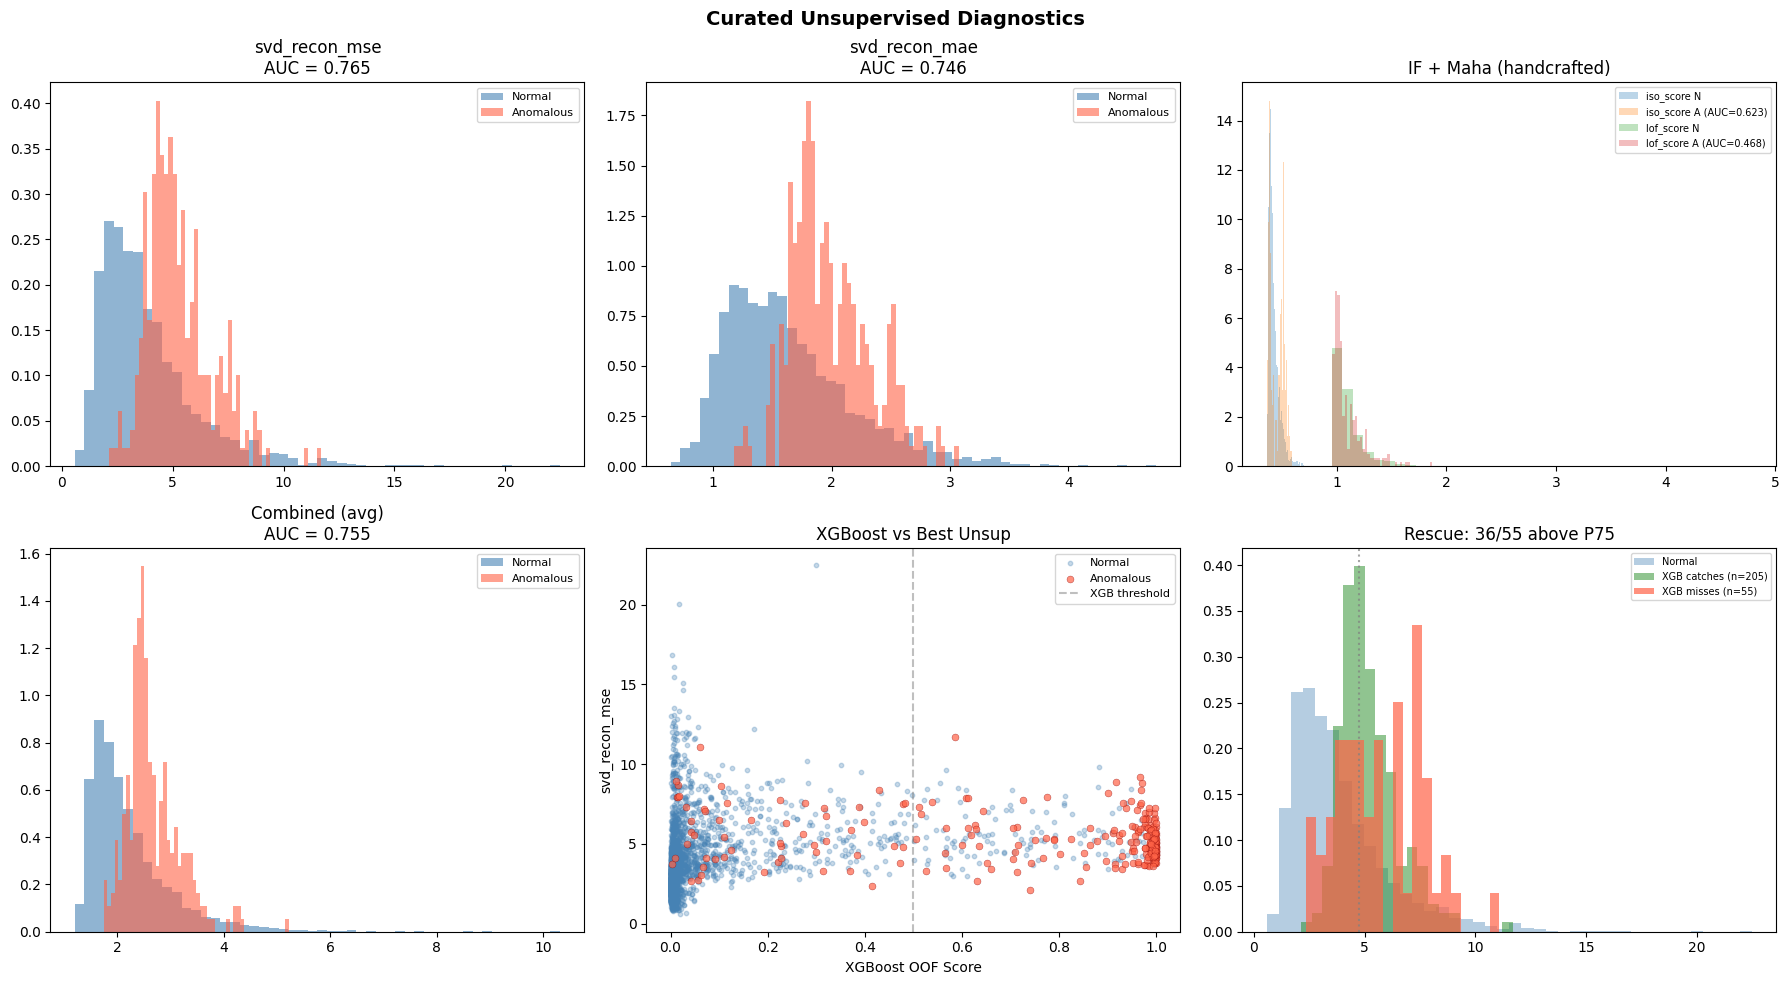


── Per-score AUCs ─────────────────────────────────────
  svd_recon_mse             AUC = 0.765
  svd_recon_mae             AUC = 0.746
  iso_score                 AUC = 0.623
  lof_score                 AUC = 0.468
  maha_score                AUC = 0.590
  combined                  AUC = 0.755

XGBoost OOF AUC: 0.963
Missed: 55/260
  rescuable: 36/55
→ Moderate. BLEND_ALPHA = 0.15–0.25


In [20]:
# ── Unsupervised Score Diagnostics ────────────────────────────────────

unsup_idxs = [feature_cols_all.index(c) for c in UNSUP_COLS]
unsup_matrix = X_trainval_s[:, unsup_idxs]

labels_bool = y_trainval.astype(bool)
normal_mask = ~labels_bool
anom_mask   = labels_bool

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Curated Unsupervised Diagnostics", fontsize=14, fontweight="bold")

# Row 1: per-score distributions
for i, (ax, name) in enumerate(zip(axes[0], UNSUP_COLS[:3])):
    vals_n = unsup_matrix[normal_mask, i]
    vals_a = unsup_matrix[anom_mask, i]
    ax.hist(vals_n, bins=50, alpha=0.6, label="Normal", density=True, color="steelblue")
    ax.hist(vals_a, bins=50, alpha=0.6, label="Anomalous", density=True, color="tomato")
    auc_i = roc_auc_score(y_trainval, unsup_matrix[:, i])
    ax.set_title(f"{name}\nAUC = {auc_i:.3f}")
    ax.legend(fontsize=8)

# Row 1, slot 3: 4th score if exists
if len(UNSUP_COLS) > 3:
    ax = axes[0][2]
    ax.clear()
    for i in [2, 3]:
        vals_a = unsup_matrix[anom_mask, i]
        vals_n = unsup_matrix[normal_mask, i]
        auc_i = roc_auc_score(y_trainval, unsup_matrix[:, i])
        ax.hist(vals_n, bins=40, alpha=0.3, density=True, label=f"{UNSUP_COLS[i]} N")
        ax.hist(vals_a, bins=40, alpha=0.3, density=True, label=f"{UNSUP_COLS[i]} A (AUC={auc_i:.3f})")
    ax.set_title("IF + Maha (handcrafted)")
    ax.legend(fontsize=7)

# Row 2, Left: combined
ax = axes[1][0]
combined = unsup_matrix.mean(axis=1)
ax.hist(combined[normal_mask], bins=50, alpha=0.6, label="Normal", density=True, color="steelblue")
ax.hist(combined[anom_mask], bins=50, alpha=0.6, label="Anomalous", density=True, color="tomato")
auc_combined = roc_auc_score(y_trainval, combined)
ax.set_title(f"Combined (avg)\nAUC = {auc_combined:.3f}")
ax.legend(fontsize=8)

# Row 2, Middle: XGBoost vs best unsupervised
ax = axes[1][1]
unsup_aucs = [roc_auc_score(y_trainval, unsup_matrix[:, i]) for i in range(unsup_matrix.shape[1])]
best_idx = np.argmax(unsup_aucs)
best_unsup = unsup_matrix[:, best_idx]
ax.scatter(oof_scores[normal_mask], best_unsup[normal_mask], alpha=0.3, s=10, c="steelblue", label="Normal")
ax.scatter(oof_scores[anom_mask], best_unsup[anom_mask], alpha=0.7, s=25, c="tomato", label="Anomalous",
           edgecolors="darkred", linewidths=0.3)
ax.axvline(0.5, color="gray", ls="--", alpha=0.5, label="XGB threshold")
ax.set_xlabel("XGBoost OOF Score")
ax.set_ylabel(f"{UNSUP_COLS[best_idx]}")
ax.set_title("XGBoost vs Best Unsup")
ax.legend(fontsize=8)

# Row 2, Right: rescue
ax = axes[1][2]
xgb_missed = anom_mask & (oof_scores < 0.5)
n_missed = xgb_missed.sum()
n_caught = (anom_mask & (oof_scores >= 0.5)).sum()
if n_missed > 0:
    unsup_missed = best_unsup[xgb_missed]
    unsup_normal = best_unsup[normal_mask]
    p75 = np.percentile(unsup_normal, 75)
    rescuable = (unsup_missed > p75).sum()
    ax.hist(unsup_normal, bins=40, alpha=0.4, density=True, color="steelblue", label="Normal")
    ax.hist(best_unsup[anom_mask & (oof_scores >= 0.5)], bins=20, alpha=0.5, density=True, color="forestgreen", label=f"XGB catches (n={n_caught})")
    ax.hist(unsup_missed, bins=20, alpha=0.7, density=True, color="tomato", label=f"XGB misses (n={n_missed})")
    ax.axvline(p75, color="gray", ls=":", alpha=0.7)
    ax.set_title(f"Rescue: {rescuable}/{n_missed} above P75")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("\n── Per-score AUCs ─────────────────────────────────────")
for name, auc in zip(UNSUP_COLS, unsup_aucs):
    print(f"  {name:25s} AUC = {auc:.3f}")
print(f"  {"combined":25s} AUC = {auc_combined:.3f}")
print(f"\nXGBoost OOF AUC: {roc_auc_score(y_trainval, oof_scores):.3f}")
print(f"Missed: {n_missed}/{anom_mask.sum()}")
if n_missed > 0:
    print(f"  rescuable: {rescuable}/{n_missed}")
if auc_combined > 0.85 and n_missed > 0 and rescuable / max(n_missed, 1) > 0.4:
    print("→ Strong. BLEND_ALPHA = 0.25–0.35")
elif auc_combined > 0.75 and n_missed > 0 and rescuable / max(n_missed, 1) > 0.2:
    print("→ Moderate. BLEND_ALPHA = 0.15–0.25")
else:
    print("→ Weak. BLEND_ALPHA = 0.10–0.15 or disable.")


#### **Model Predictions**

In [21]:
# Load test data
XX_test, _ = load_npz("data/third_batch.npz")

In [22]:
# ── Test predictions ──────────────────────────────────────────────────
fold_test_preds = []

for fold_id, art in enumerate(fold_artifacts, 1):
    model           = art["model"]
    item_stats_fold = art["item_stats"]
    feat_cols_fold  = art["feature_cols"]
    scaler_fold     = art["scaler"]
    normal_users_fold = art["normal_users"]
    struct_refs_fold  = art["struct_refs"]

    test_df = build_all_features(XX_test, item_stats_fold, struct_refs_fold)
    hc_cols_fold = [c for c in feat_cols_fold if c not in UNSUP_COLS]

    for c in hc_cols_fold:
        if c not in test_df.columns:
            test_df[c] = 0.0

    X_test_hc_s = scaler_fold.transform(test_df[hc_cols_fold].values)

    # Reference = full training set for IF/LOF/Maha
    ref_df = build_all_features(XX_all, item_stats_fold, struct_refs_fold)
    for c in hc_cols_fold:
        if c not in ref_df.columns:
            ref_df[c] = 0.0
    X_ref_hc_s = scaler_fold.transform(ref_df[hc_cols_fold].values)

    unsup_test, _ = build_unsupervised_scores(
        XX_ref=XX_all, XX_target=XX_test,
        target_users=test_df["user"].values,
        ref_normal_users=normal_users_fold,
        X_handcrafted_ref=X_ref_hc_s,
        X_handcrafted_target=X_test_hc_s,
    )

    X_test_final = np.hstack([X_test_hc_s, unsup_test])
    p_test = model.predict_proba(X_test_final)[:, 1]
    fold_test_preds.append(p_test)
    print(f"Generated test predictions from fold {fold_id:02d}")

fold_test_preds = np.column_stack(fold_test_preds)
y_score_raw = fold_test_preds.mean(axis=1)

# ── Standalone SVD recon MSE for blending ─────────────────────────
unsup_blend, _ = build_unsupervised_scores(
    XX_ref=XX_all, XX_target=XX_test,
    target_users=build_all_features(XX_test, item_stats_full, struct_refs_full)["user"].values,
    ref_normal_users=normal_users_all,
    X_handcrafted_ref=X_hc_s,
    X_handcrafted_target=scaler.transform(
        build_all_features(XX_test, item_stats_full, struct_refs_full)
        .reindex(columns=hc_cols, fill_value=0).values
    ),
)
recon_mse_test = unsup_blend[:, 0]
recon_norm = (recon_mse_test - recon_mse_test.min()) / (
    recon_mse_test.max() - recon_mse_test.min() + 1e-9
)

print(f"\nXGBoost raw range:  [{y_score_raw.min():.4f}, {y_score_raw.max():.4f}]")
print(f"SVD recon range:    [{recon_norm.min():.4f}, {recon_norm.max():.4f}]")

# Blend (same BLEND_ALPHA as calibration cell)
y_blended = (1 - BLEND_ALPHA) * y_score_raw + BLEND_ALPHA * recon_norm

y_score_cal = calibrator.predict_proba(y_blended.reshape(-1, 1))[:, 1]
y_score_norm = (y_score_cal - y_score_cal.min()) / (
    y_score_cal.max() - y_score_cal.min() + 1e-9
)

print(f"\nFinal shape: {y_score_norm.shape}")
print(f"Final range: [{y_score_norm.min():.4f}, {y_score_norm.max():.4f}]")


Generated test predictions from fold 01
Generated test predictions from fold 02
Generated test predictions from fold 03
Generated test predictions from fold 04
Generated test predictions from fold 05

XGBoost raw range:  [0.0006, 0.9965]
SVD recon range:    [0.0000, 1.0000]

Final shape: (1625,)
Final range: [0.0000, 1.0000]


#### **Evaluation (local/Codabench)**

In [23]:
# Save submission
np.savez("submission.npz", predictions=y_score_norm)
with zipfile.ZipFile("submission.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write("submission.npz", arcname="submission.npz")
pd.DataFrame({"predictions": y_score_norm}).to_csv("submission.csv", index=False)
print("submission.zip ready for Codabench")

submission.zip ready for Codabench


# **XGBoost_unsup_feat_scores.zip** 
- blend_alpha = 0.08

AUC:       0.9195
Precision: 0.6092
Recall:    0.4240
F1 Score:  0.5000

# **XGBoost_unsup_feat_scores2.zip** 
- blend_alpha = 0.15
AUC:       0.9009
Precision: 0.6163
Recall:    0.4240
F1 Score:  0.5024
